<a href="https://colab.research.google.com/github/ongtrieuhoaiphuc-oi/vscode-tunnel/blob/main/vscode_tunnel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2026-07-12 03:39:41 | INFO     | vscode_colab.server:download_vscode_cli:74 - Downloading VS Code CLI (cli-alpine-x64) to /content/vscode_cli_alpine_x64.tar.gz...


🆔 SESSION_ID  : b9e2ddd4
🔗 TUNNEL_NAME : colab-b9e2ddd4
🖥️  HOSTNAME    : 221a70b338ff
⏱️  STARTED_AT  : 2026-07-12 03:39:41
📄 File định danh: /content/.session_identity.txt
🔑 Đang chờ đăng nhập GitHub... hoàn tất device code ở link phía trên.


2026-07-12 03:39:42 | INFO     | vscode_colab.server:download_vscode_cli:87 - VS Code CLI tarball downloaded. Extracting...
2026-07-12 03:39:43 | INFO     | vscode_colab.server:download_vscode_cli:171 - VS Code CLI setup successful. Executable at: '/content/code'.
2026-07-12 03:39:43 | INFO     | vscode_colab.server:_login:220 - Initiating VS Code Tunnel login with command: /content/code tunnel user login --provider github
2026-07-12 03:39:43 | INFO     | vscode_colab.server:_login:254 - Monitoring login process output for GitHub authentication URL and code...
2026-07-12 03:39:43 | INFO     | vscode_colab.server:_login:272 - Detected authentication URL: https://github.com/login/device
2026-07-12 03:39:43 | INFO     | vscode_colab.server:_login:278 - Detected authentication code: FF47-54AA
2026-07-12 03:39:43 | INFO     | vscode_colab.server:_login:281 - Authentication URL and code detected. Displaying to user.


2026-07-12 03:39:43 | INFO     | vscode_colab.server:login:200 - Login successful: Set environment variable VSCODE_COLAB_LOGGED_IN=true


✅ Login thành công! Đang mở tunnel (không auto-install extension)...
*
* Visual Studio Code Server
*
* By using the software, you agree to
* the Visual Studio Code Server License Terms (https://aka.ms/vscode-server-license) and
* the Microsoft Privacy Statement (https://privacy.microsoft.com/en-US/privacystatement).
*
[2026-07-12 03:39:43] info Using GitHub for authentication, run `code tunnel user login --provider <provider>` option to change this.
To grant access to the server, please log into https://github.com/login/device and use code BDCF-D663
[2026-07-12 03:41:08] info Creating tunnel with the name: colab-b9e2ddd4

  Visual Studio Code Tunnel v1.127.0

  ➜  Tunnel:   colab-b9e2ddd4
  ➜  Open:  https://vscode.dev/tunnel/colab-b9e2ddd4/content

🌐 Link VS Code Web : https://vscode.dev/tunnel/colab-b9e2ddd4/
🆔 SESSION_ID       : b9e2ddd4   ← nhớ số này để đối chiếu


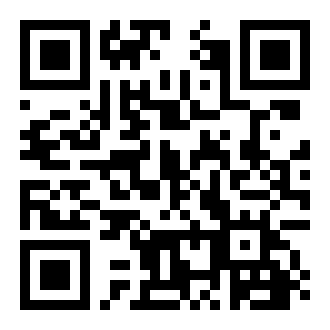

👉 Vào web xong, mở Terminal, gõ: cat /content/.session_identity.txt
   Nếu SESSION_ID hiện ra = b9e2ddd4 → đúng tunnel, đúng máy.


In [ ]:
# ============================================
# 1 CELL: clean cache → login → tunnel (KHÔNG extension) → QR + SESSION ID
# ============================================
import importlib.util, subprocess, sys, time, uuid, datetime, socket

# BƯỚC 0: dọn cache VS Code hỏng
subprocess.run("rm -rf /root/.vscode /root/.vscode-server /root/.vscode-cli", shell=True)

# BƯỚC 1: cài deps nếu thiếu
if importlib.util.find_spec("vscode_colab") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "vscode-colab"], check=True)
if importlib.util.find_spec("qrcode") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "qrcode[pil]"], check=True)

import vscode_colab, qrcode
from IPython.display import display

# --- TẠO SESSION ID DUY NHẤT CHO PHIÊN NÀY ---
SESSION_ID = uuid.uuid4().hex[:8]                     # vd: a3f9c1b2
STARTED_AT = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
TUNNEL_NAME = f"colab-{SESSION_ID}"                   # tên tunnel gắn liền session, tránh trùng phiên cũ
IDENTITY_FILE = "/content/.session_identity.txt"
CODE_BIN = "/content/code"

# ghi file định danh ngay từ đầu, trước cả khi login/connect
with open(IDENTITY_FILE, "w") as f:
    f.write(f"SESSION_ID   : {SESSION_ID}\n")
    f.write(f"TUNNEL_NAME  : {TUNNEL_NAME}\n")
    f.write(f"HOSTNAME     : {socket.gethostname()}\n")
    f.write(f"STARTED_AT   : {STARTED_AT}\n")

print("=" * 55)
print(f"🆔 SESSION_ID  : {SESSION_ID}")
print(f"🔗 TUNNEL_NAME : {TUNNEL_NAME}")
print(f"🖥️  HOSTNAME    : {socket.gethostname()}")
print(f"⏱️  STARTED_AT  : {STARTED_AT}")
print(f"📄 File định danh: {IDENTITY_FILE}")
print("=" * 55)

# BƯỚC 2: login GitHub
print("🔑 Đang chờ đăng nhập GitHub... hoàn tất device code ở link phía trên.")
auth = vscode_colab.login()

if not auth:
    print("❌ Login CHƯA thành công. Hoàn tất device code rồi chạy lại cell. Chưa hiện QR.")
else:
    print("✅ Login thành công! Đang mở tunnel (không auto-install extension)...")

    proc = subprocess.Popen(
        [CODE_BIN, "tunnel", "--accept-server-license-terms", "--name", TUNNEL_NAME],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="")
        if "Open this link" in line or "vscode.dev/tunnel" in line or "is now available" in line.lower():
            break
    time.sleep(2)

    web_url = f"https://vscode.dev/tunnel/{TUNNEL_NAME}/"
    print("\n" + "=" * 55)
    print(f"🌐 Link VS Code Web : {web_url}")
    print(f"🆔 SESSION_ID       : {SESSION_ID}   ← nhớ số này để đối chiếu")
    print("=" * 55)

    qr = qrcode.QRCode(border=2)
    qr.add_data(web_url)
    qr.make()
    display(qr.make_image())

    print("👉 Vào web xong, mở Terminal, gõ: cat /content/.session_identity.txt")
    print(f"   Nếu SESSION_ID hiện ra = {SESSION_ID} → đúng tunnel, đúng máy.")

In [ ]:
# Kiểm tra đang thao tác đúng phiên trước khi cài extension
with open("/content/.session_identity.txt") as f:
    print(f.read())

exts = ["ms-python.python", "ms-toolsai.jupyter", "ms-python.debugpy"]
for e in exts:
    print(f"📦 Cài {e} ...")
    subprocess.run([CODE_BIN, "--install-extension", e, "--force"], check=False)
print("✅ Xong. Reload lại tab VS Code web (Ctrl+R).")

SESSION_ID   : b9e2ddd4
TUNNEL_NAME  : colab-b9e2ddd4
HOSTNAME     : 221a70b338ff
STARTED_AT   : 2026-07-12 03:39:41

📦 Cài ms-python.python ...
📦 Cài ms-toolsai.jupyter ...
📦 Cài ms-python.debugpy ...
✅ Xong. Reload lại tab VS Code web (Ctrl+R).


In [ ]:
# BƯỚC 5: cài opencode CLI (dùng npm cho ổn định, không phụ thuộc curl pipe)
print("\n📦 Đang cài opencode CLI...")
r = subprocess.run(
    "npm i -g opencode-ai@latest 2>&1 | tail -20",
    shell=True, text=True
)
check = subprocess.run(["which", "opencode"], capture_output=True, text=True)
if check.stdout.strip():
    ver = subprocess.run(["opencode", "--version"], capture_output=True, text=True)
    print(f"✅ opencode đã cài: {check.stdout.strip()}  (version: {ver.stdout.strip()})")
else:
    print("⚠️ opencode chưa thấy trong PATH, kiểm tra lại: npm root -g")


📦 Đang cài opencode CLI...
✅ opencode đã cài: /tools/node/bin/opencode  (version: 1.17.18)
